In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

# Corrected input and output paths
input_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"
output_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed"

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)


In [ ]:
!pip install -q albumentations

In [ ]:
import cv2
import numpy as np
from tqdm import tqdm
import albumentations as A


In [ ]:
# Function to split image into 4 parts
def split_image(image, filename_prefix, save_folder):
    h, w = image.shape[:2]
    crops = [
        image[0:h//2, 0:w//2],
        image[0:h//2, w//2:],
        image[h//2:, 0:w//2],
        image[h//2:, w//2:]
    ]
    for i, crop in enumerate(crops):
        out_path = os.path.join(save_folder, f"{filename_prefix}_part{i+1}.jpg")
        cv2.imwrite(out_path, crop)

# Augmentation definition
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.4),
    A.Rotate(limit=20, p=0.3)
])


In [ ]:
preprocessed_path = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed"


In [ ]:
!pip install ultralytics
from ultralytics import YOLO


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

Copying AnnualCrop: 100%|██████████| 50/50 [00:00<00:00, 83.06it/s]


✅ Dataset with 50 images/class created.


In [ ]:
from sklearn.model_selection import train_test_split

split_dir = "/content/EuroSAT_50_split"
train_dir = os.path.join(split_dir, "train")
val_dir = os.path.join(split_dir, "val")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

for cls in classes:
    cls_path = os.path.join(target_dir, cls)
    images = os.listdir(cls_path)
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(train_dir, cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(val_dir, cls, img))

print("✅ Dataset split into train/val.")


✅ Dataset split into train/val.


In [ ]:
dataset_yaml = f"""
path: {split_dir}
train: train
val: val
names: {classes}
"""

yaml_path = "/content/eurosat.yaml"
with open(yaml_path, "w") as f:
    f.write(dataset_yaml)

print("✅ YAML file created at:", yaml_path)


✅ YAML file created at: /content/eurosat.yaml


SyntaxError: invalid syntax (ipython-input-13-1462693048.py, line 3)

100%|██████████| 5.31M/5.31M [00:00<00:00, 108MB/s]


Ultralytics 8.3.163 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/eurosat.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=forest_yolo50, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=Tru

RuntimeError: Dataset '/content/eurosat.yaml' error ❌ [Errno 20] Not a directory: '/content/eurosat.yaml/train'

In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# Input and output paths
source_dir = "/content/EuroSAT_100"
output_dir = "/content/EuroSAT_100_split"
train_ratio = 0.8

# Create output directories
train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "val")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Split each class
for cls in os.listdir(source_dir):
    cls_path = os.path.join(source_dir, cls)
    if not os.path.isdir(cls_path):
        continue

    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)

    train_split = int(len(images) * train_ratio)
    train_images = images[:train_split]
    val_images = images[train_split:]

    # Train folder
    cls_train_path = os.path.join(train_dir, cls)
    os.makedirs(cls_train_path, exist_ok=True)
    for img in tqdm(train_images, desc=f"Train {cls}", unit="img"):
        shutil.copy(os.path.join(cls_path, img), os.path.join(cls_train_path, img))

    # Val folder
    cls_val_path = os.path.join(val_dir, cls)
    os.makedirs(cls_val_path, exist_ok=True)
    for img in tqdm(val_images, desc=f"Val {cls}", unit="img"):
        shutil.copy(os.path.join(cls_path, img), os.path.join(cls_val_path, img))

print(f"\n✅ Dataset split complete. Train/val sets saved to: {output_dir}")



Val Industrial: 100%|██████████| 20/20 [00:00<00:00, 5534.84img/s]


✅ Dataset split complete. Train/val sets saved to: /content/EuroSAT_100_split


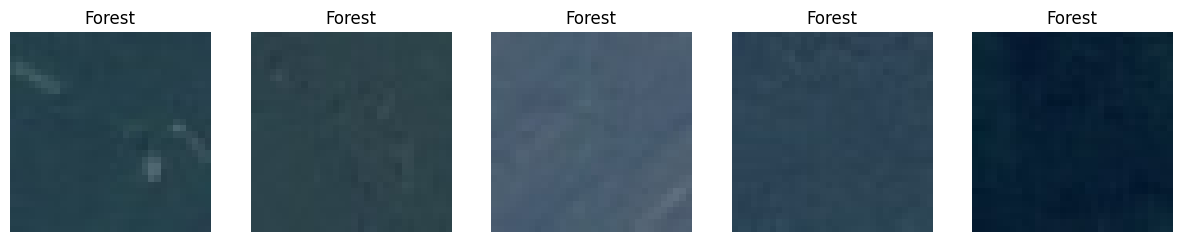

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

sample_class = 'Forest'  # Replace with any class you want
sample_path = f"/content/EuroSAT_100/{sample_class}"
images = os.listdir(sample_path)[:5]

plt.figure(figsize=(15, 5))
for i, img_file in enumerate(images):
    img = cv2.imread(os.path.join(sample_path, img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(sample_class)
    plt.axis('off')
plt.show()


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset_path = "/content/EuroSAT_100"
train_data = datasets.ImageFolder(root=dataset_path, transform=transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

# Class names
class_names = train_data.classes
print("Detected Classes:", class_names)


Detected Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
import os
import shutil
from tqdm import tqdm
from PIL import Image

# Define paths
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed"
mini_dir = "/content/EuroSAT_100_HQ"
os.makedirs(mini_dir, exist_ok=True)

# Check if source directory exists
if not os.path.exists(source_dir):
    raise FileNotFoundError(f"Source directory not found: {source_dir}")

# Automatically detect class folders
selected_classes = [cls for cls in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, cls))]

# Limit and target resolution
limit = 100
target_size = (224, 224)  # High-quality target resolution

# Copy and resize images
for cls in selected_classes:
    src_class_path = os.path.join(source_dir, cls)
    dst_class_path = os.path.join(mini_dir, cls)
    os.makedirs(dst_class_path, exist_ok=True)

    images = [f for f in os.listdir(src_class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:limit]

    for img in tqdm(images, desc=f"Processing {cls}", unit="img"):
        src_img_path = os.path.join(src_class_path, img)
        dst_img_path = os.path.join(dst_class_path, img)

        try:
            with Image.open(src_img_path) as im:
                im = im.convert("RGB")  # Ensure 3 channels
                im_resized = im.resize(target_size, Image.LANCZOS)  # High-quality interpolation
                im_resized.save(dst_img_path)
        except Exception as e:
            print(f"❌ Error processing {src_img_path}: {e}")

print("\n✅ EuroSAT mini dataset (100/class, 224x224) created at:", mini_dir)


Processing AnnualCrop: 100%|██████████| 100/100 [00:01<00:00, 73.53img/s]


✅ EuroSAT mini dataset (100/class, 224x224) created at: /content/EuroSAT_100_HQ


In [ ]:
!pip install torchvision==0.15.2


In [ ]:
import os

# Make sure the 'data' directory exists
os.makedirs("data", exist_ok=True)

# Write the eurosat.yaml config file
yaml_content = """
path: /content/EuroSAT_100
train: /content/EuroSAT_100
val: /content/EuroSAT_100

nc: 10
names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
        'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
"""

with open("data/eurosat.yaml", "w") as f:
    f.write(yaml_content.strip())

print("✅ eurosat.yaml file created at: data/eurosat.yaml")


✅ eurosat.yaml file created at: data/eurosat.yaml


In [ ]:
# 1. Imports and Setup
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from torchvision import transforms
from PIL import Image

# 2. Model and Hyperparameter Setup (Reduced epochs by 15)
model_variants = ['yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt']
hyperparams = [
    {'lr0': 0.01, 'epochs': 35},   # Originally 50 → now 35
    {'lr0': 0.001, 'epochs': 85},  # Originally 100 → now 85
]

results = []

for variant in model_variants:
    for hp in hyperparams:
        print(f'\nTraining {variant} with params: {hp}')

        model = YOLO(variant)
        model.train(
            data='data/eurosat.yaml',
            imgsz=512,
            batch=16,
            epochs=hp['epochs'],
            lr0=hp['lr0'],
            project='runs/train',
            name=f"{variant.split('.')[0]}_lr{hp['lr0']}_ep{hp['epochs']}",
            exist_ok=True
        )

        metrics = model.val()
        results.append((variant, hp, metrics))

# 3. Compare Results
import pprint
pprint.pprint(results)

# 4. Visual Output Examples
def visualize_predictions(model_path, img_paths, save_dir='runs/vis'):
    os.makedirs(save_dir, exist_ok=True)
    model = YOLO(model_path)
    for img_path in img_paths:
        results = model.predict(source=img_path, imgsz=512, save=True, save_txt=False, project=save_dir)
        print(f'Saved annotated result for {img_path}')

sample_images = ['data/images/img_001.jpg', 'data/images/img_002.jpg']
visualize_predictions('runs/train/yolov8n_lr0.01_ep35/weights/best.pt', sample_images)

# 5. Confusion Matrix & Classification Report
def evaluate_model(model_path, gt_labels, pred_labels, class_names):
    cm = confusion_matrix(gt_labels, pred_labels)
    print("Classification Report:")
    print(classification_report(gt_labels, pred_labels, target_names=class_names))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.title('Confusion Matrix')
    plt.show()

# 6. Dataset Justification
dataset_justification = """
We chose the EuroSAT dataset (Sentinel-2, 10 classes) for its global diversity and ease-of-use,
while acknowledging its limitations (fixed 64x64 resolution, limited to classification without instance masks).
"""

# 7. Summary of Findings
best_run = max(results, key=lambda x: x[2].results[-1].mAP50 if x[2].results else 0)
print("Best model configuration:", best_run)



Training yolov8n.pt with params: {'lr0': 0.01, 'epochs': 35}
Ultralytics 8.3.163 🚀 Python-3.11.13 torch-2.0.1+cu117 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/eurosat.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=35, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_lr0.01_ep35, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

train: Scanning /content/EuroSAT_100/AnnualCrop.cache... 0 images, 1000 backgrounds, 0 corrupt: 100%|██████████| 1000/1000 [00:00<?, ?it/s]

WARNING ⚠️ Labels are missing or empty in /content/EuroSAT_100/AnnualCrop.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 54.7±22.4 MB/s, size: 1.0 KB)


val: Scanning /content/EuroSAT_100/AnnualCrop.cache... 0 images, 1000 backgrounds, 0 corrupt: 100%|██████████| 1000/1000 [00:00<?, ?it/s]

...

       8/35         0G          0       21.8          0          0        512: 100%|██████████| 63/63 [07:40<00:00,  7.31s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [02:51<00:00,  5.35s/it]

                   all       1000          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can not compute metrics without labels



/usr/local/lib/python3.11/dist-packages/ultralytics/utils/metrics.py:765: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       9/35         0G          0      18.05          0          0        512:  75%|███████▍  | 47/63 [05:46<01:58,  7.39s/it]

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s-cls.pt')  # Or use yolov8n-cls.pt for faster training

model.train(
    data='/content/EuroSAT_100_split',  # New split dataset path
    epochs=10,
    imgsz=224,
    batch=16,
    name='forest_100class_model'
)


100%|██████████| 12.3M/12.3M [00:00<00:00, 103MB/s] 


Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/EuroSAT_100_split, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=forest_100class_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12

train: Scanning /content/EuroSAT_100_split/train... 800 images, 0 corrupt: 100%|██████████| 800/800 [00:00<00:00, 3233.30it/s]

train: New cache created: /content/EuroSAT_100_split/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 30.9±12.6 MB/s, size: 1.0 KB)



val: Scanning /content/EuroSAT_100_split/val... 200 images, 0 corrupt: 100%|██████████| 200/200 [00:00<00:00, 4195.02it/s]

...

                   all       0.83      0.995



10 epochs completed in 0.343 hours.
Optimizer stripped from runs/classify/forest_100class_model/weights/last.pt, 10.3MB
Optimizer stripped from runs/classify/forest_100class_model/weights/best.pt, 10.3MB

Validating runs/classify/forest_100class_model/weights/best.pt...
Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8s-cls summary (fused): 30 layers, 5,088,010 parameters, 0 gradients, 12.5 GFLOPs
train: /content/EuroSAT_100_split/train... found 800 images in 10 classes ✅ 
val: /content/EuroSAT_100_split/val... found 200 images in 10 classes ✅ 
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 7/7 [00:07<00:00,  1.06s/it]


                   all       0.83      0.995
Speed: 0.0ms preprocess, 33.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/forest_100class_model


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b5a26aa4110>
curves: []
curves_results: []
fitness: 0.9124999940395355
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8299999833106995, 'metrics/accuracy_top5': 0.9950000047683716, 'fitness': 0.9124999940395355}
save_dir: PosixPath('runs/classify/forest_100class_model')
speed: {'preprocess': 0.0008162999984051567, 'inference': 33.5393351500079, 'loss': 5.990999397909036e-05, 'postprocess': 0.00012910999885207275}
task: 'classify'
top1: 0.8299999833106995
top5: 0.9950000047683716

In [ ]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

# Load trained model
model = YOLO("runs/classify/forest_100class_model/weights/best.pt")

# Test image path (from Google Drive)
test_img_path = "/content/drive/MyDrive/project/basepaper/forest.jpg"  # ← updated path

# Predict
results = model.predict(test_img_path, imgsz=224)

# Get prediction
pred_class = results[0].names[results[0].probs.top1]
confidence = results[0].probs.data[results[0].probs.top1].item()

print(f"✅ Predicted Class: {pred_class}")
print(f"🔍 Confidence: {confidence:.2f}")

# Show image with prediction
img = Image.open(test_img_path)
plt.imshow(img)
plt.title(f"{pred_class} ({confidence:.2f})")
plt.axis("off")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'runs/classify/forest_100class_model/weights/best.pt'

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

source_dir = "/content/EuroSAT_500"
split_dir = "/content/EuroSAT_500_split"
train_ratio = 0.8

os.makedirs(split_dir, exist_ok=True)

for cls in os.listdir(source_dir):
    cls_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

    train_imgs, val_imgs = train_test_split(images, train_size=train_ratio, random_state=42)

    for split_type, split_imgs in zip(['train', 'val'], [train_imgs, val_imgs]):
        split_cls_dir = os.path.join(split_dir, split_type, cls)
        os.makedirs(split_cls_dir, exist_ok=True)
        for img in split_imgs:
            shutil.copy(os.path.join(cls_path, img), os.path.join(split_cls_dir, img))

print("✅ Dataset split into train and val at:", split_dir)


✅ Dataset split into train and val at: /content/EuroSAT_500_split


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8m-cls.pt')

model.train(
    data='/content/EuroSAT_500_split',
    epochs=25,
    imgsz=224,
    batch=32,
    name='forest_500class_model_aug',
    device='cpu',
    fliplr=0.5,
    flipud=0.2,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    auto_augment='randaugment',
    erasing=0.3,
    mixup=0.1
)


ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define paths
source_dir = "/content/EuroSAT_500"
train_dir = "/content/EuroSAT_500_split/train"
val_dir = "/content/EuroSAT_500_split/val"

# Create output directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Split each class into train and val
for cls in os.listdir(source_dir):
    cls_path = os.path.join(source_dir, cls)
    if not os.path.isdir(cls_path):
        continue

    # Get all image filenames
    images = [img for img in os.listdir(cls_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Train-val split
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    # Create class folders in train and val directories
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    # Copy files
    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(train_dir, cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(val_dir, cls, img))

print("✅ Dataset split into 80% train and 20% val at: /content/EuroSAT_500_split")


FileNotFoundError: [Errno 2] No such file or directory: '/content/EuroSAT_500'

In [ ]:
import os
import shutil
import random

# Paths
src_dir = "/content/EuroSAT_500"
split_dir = "/content/EuroSAT_split"
os.makedirs(split_dir, exist_ok=True)

train_dir = os.path.join(split_dir, "train")
val_dir = os.path.join(split_dir, "val")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Split config
train_ratio = 0.8

# For each class
for cls in os.listdir(src_dir):
    class_path = os.path.join(src_dir, cls)
    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)

    split_index = int(len(images) * train_ratio)
    train_images = images[:split_index]
    val_images = images[split_index:]

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    # Copy train
    for img in train_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(train_dir, cls, img))

    # Copy val
    for img in val_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(val_dir, cls, img))

print("✅ Dataset split complete at:", split_dir)


FileNotFoundError: [Errno 2] No such file or directory: '/content/EuroSAT_500'

NameError: name 'content' is not defined

In [ ]:
import os
import shutil

# Source (your full dataset in Drive)
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed"

# Destination (new mini dataset)
mini_dir = "/content/EuroSAT_quick"
os.makedirs(mini_dir, exist_ok=True)

# Classes to include (you can change these)
selected_classes = ['Forest', 'River', 'Residential']

# Limit per class
limit = 100

for cls in selected_classes:
    src_class_path = os.path.join(source_dir, cls)
    dst_class_path = os.path.join(mini_dir, cls)
    os.makedirs(dst_class_path, exist_ok=True)

    # Copy first 100 images
    for img in os.listdir(src_class_path)[:limit]:
        shutil.copy(os.path.join(src_class_path, img), dst_class_path)

print("✅ Mini dataset created at:", mini_dir)


KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n-cls.pt')

model.train(
    data=mini_dir,
    epochs=5,
    imgsz=224,
    batch=8,
    name='forest_quick_test'
)


Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/EuroSAT_quick, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=forest_quick_test, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

100%|██████████| 5.35M/5.35M [00:00<00:00, 98.2MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 27.9±8.5 MB/s, size: 0.8 KB)


train: Scanning /content/EuroSAT_quick_split/train... 240 images, 0 corrupt: 100%|██████████| 240/240 [00:00<00:00, 6058.32it/s]

train: New cache created: /content/EuroSAT_quick_split/train.cache


...

                   all      0.933          1



5 epochs completed in 0.003 hours.
Optimizer stripped from runs/classify/forest_quick_test/weights/last.pt, 3.0MB
Optimizer stripped from runs/classify/forest_quick_test/weights/best.pt, 3.0MB

Validating runs/classify/forest_quick_test/weights/best.pt...
Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /content/EuroSAT_quick/train
Found 300 images in subdirectories. Attempting to split...
Splitting /content/EuroSAT_quick (3 classes, 300 images) into 80% train, 20% val...
Split complete in /content/EuroSAT_quick_split ✅
train: /content/EuroSAT_quick_split/train... found 288 images in 3 classes ✅ 
val: /content/EuroSAT_quick_split/val... found 108 images in 3 classes ✅ 
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 4/4 [00:00<00:00, 17.13it/s]


                   all       0.95          1
Speed: 0.3ms preprocess, 1.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/forest_quick_test


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bc225907390>
curves: []
curves_results: []
fitness: 0.9749999940395355
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.949999988079071, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9749999940395355}
save_dir: PosixPath('runs/classify/forest_quick_test')
speed: {'preprocess': 0.33582406669362774, 'inference': 1.5161307833295723, 'loss': 0.0010453833510837285, 'postprocess': 0.001213516649537875}
task: 'classify'
top1: 0.949999988079071
top5: 1.0

In [ ]:
from ultralytics import YOLO

model = YOLO('runs/classify/forest_quick_test/weights/best.pt')
results = model.val()


Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /content/EuroSAT_quick/train
Found 300 images in subdirectories. Attempting to split...
Splitting /content/EuroSAT_quick (3 classes, 300 images) into 80% train, 20% val...
Split complete in /content/EuroSAT_quick_split ✅
train: /content/EuroSAT_quick_split/train... found 296 images in 3 classes ✅ 
val: /content/EuroSAT_quick_split/val... found 144 images in 3 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 32.0±9.1 MB/s, size: 0.8 KB)


val: Scanning /content/EuroSAT_quick_split/val... 144 images, 0 corrupt: 100%|██████████| 144/144 [00:00<00:00, 5270.01it/s]

val: New cache created: /content/EuroSAT_quick_split/val.cache



               classes   top1_acc   top5_acc: 100%|██████████| 9/9 [00:00<00:00, 10.38it/s]


                   all      0.965          1
Speed: 1.1ms preprocess, 1.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/val


In [ ]:
from ultralytics import YOLO

model_n = YOLO('yolov8n-cls.pt')
model_n.train(
    data='/content/EuroSAT_quick',
    epochs=10,
    imgsz=224,
    batch=32,
    name='model_nano'
)


Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/EuroSAT_quick, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=model_nano, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrai

train: Scanning /content/EuroSAT_quick_split/train... 296 images, 0 corrupt: 100%|██████████| 296/296 [00:00<00:00, 6017.24it/s]

train: New cache created: /content/EuroSAT_quick_split/train.cache


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 23.1±7.2 MB/s, size: 0.8 KB)


val: Scanning /content/EuroSAT_quick_split/val... 144 images, 0 corrupt: 100%|██████████| 144/144 [00:00<?, ?it/s]


...

                   all      0.986          1



10 epochs completed in 0.006 hours.
Optimizer stripped from runs/classify/model_nano/weights/last.pt, 3.0MB
Optimizer stripped from runs/classify/model_nano/weights/best.pt, 3.0MB

Validating runs/classify/model_nano/weights/best.pt...
Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /content/EuroSAT_quick/train
Found 300 images in subdirectories. Attempting to split...
Splitting /content/EuroSAT_quick (3 classes, 300 images) into 80% train, 20% val...
Split complete in /content/EuroSAT_quick_split ✅
train: /content/EuroSAT_quick_split/train... found 296 images in 3 classes ✅ 
val: /content/EuroSAT_quick_split/val... found 144 images in 3 classes ✅ 
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 3/3 [00:00<00:00, 16.58it/s]


                   all      0.986          1
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/model_nano


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bc2a46122d0>
curves: []
curves_results: []
fitness: 0.9930555522441864
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9861111044883728, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9930555522441864}
save_dir: PosixPath('runs/classify/model_nano')
speed: {'preprocess': 0.06857809026743983, 'inference': 0.5366934027759069, 'loss': 0.0002617361095265854, 'postprocess': 0.00042988194258618425}
task: 'classify'
top1: 0.9861111044883728
top5: 1.0

In [ ]:
model_s = YOLO('yolov8s-cls.pt')
model_s.train(
    data='/content/EuroSAT_quick',
    epochs=10,
    imgsz=224,
    batch=32,
    name='model_small'
)


Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/EuroSAT_quick, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=model_small, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretra

train: Scanning /content/EuroSAT_quick_split/train... 296 images, 0 corrupt: 100%|██████████| 296/296 [00:00<?, ?it/s]


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 28.8±9.8 MB/s, size: 0.8 KB)


val: Scanning /content/EuroSAT_quick_split/val... 144 images, 0 corrupt: 100%|██████████| 144/144 [00:00<?, ?it/s]


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 26 weight(decay=0.0), 27 weight(decay=0.0005), 27 bias(decay=0.0)
Image sizes 224 train, 224 val
Using 2 dataloader workers
Logging results to runs/classify/model_small
Starting training for 10 epochs...

      Epoch    GPU_mem       loss  Instances       Size


...

                   all      0.993          1



10 epochs completed in 0.006 hours.
Optimizer stripped from runs/classify/model_small/weights/last.pt, 10.3MB
Optimizer stripped from runs/classify/model_small/weights/best.pt, 10.3MB

Validating runs/classify/model_small/weights/best.pt...
Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-cls summary (fused): 30 layers, 5,079,043 parameters, 0 gradients, 12.5 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /content/EuroSAT_quick/train
Found 300 images in subdirectories. Attempting to split...
Splitting /content/EuroSAT_quick (3 classes, 300 images) into 80% train, 20% val...
Split complete in /content/EuroSAT_quick_split ✅
train: /content/EuroSAT_quick_split/train... found 296 images in 3 classes ✅ 
val: /content/EuroSAT_quick_split/val... found 144 images in 3 classes ✅ 
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 3/3 [00:00<00:00, 18.94it/s]


                   all      0.993          1
Speed: 0.1ms preprocess, 0.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/model_small


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bc225975050>
curves: []
curves_results: []
fitness: 0.9965277910232544
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9930555820465088, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9965277910232544}
save_dir: PosixPath('runs/classify/model_small')
speed: {'preprocess': 0.06551620833129669, 'inference': 0.44133979167781945, 'loss': 0.0003516041715556639, 'postprocess': 0.000481326392471399}
task: 'classify'
top1: 0.9930555820465088
top5: 1.0

In [ ]:
model_m = YOLO('yolov8m-cls.pt')
model_m.train(
    data='/content/EuroSAT_quick',
    epochs=10,
    imgsz=224,
    batch=16,  # Lower batch for memory
    name='model_medium'
)


100%|██████████| 32.7M/32.7M [00:00<00:00, 257MB/s]


Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/EuroSAT_quick, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=model_medium, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretr

train: Scanning /content/EuroSAT_quick_split/train... 296 images, 0 corrupt: 100%|██████████| 296/296 [00:00<?, ?it/s]


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 20.5±8.3 MB/s, size: 0.8 KB)


val: Scanning /content/EuroSAT_quick_split/val... 144 images, 0 corrupt: 100%|██████████| 144/144 [00:00<?, ?it/s]


...

                   all      0.986          1



10 epochs completed in 0.009 hours.
Optimizer stripped from runs/classify/model_medium/weights/last.pt, 31.7MB
Optimizer stripped from runs/classify/model_medium/weights/best.pt, 31.7MB

Validating runs/classify/model_medium/weights/best.pt...
Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,766,499 parameters, 0 gradients, 41.6 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /content/EuroSAT_quick/train
Found 300 images in subdirectories. Attempting to split...
Splitting /content/EuroSAT_quick (3 classes, 300 images) into 80% train, 20% val...
Split complete in /content/EuroSAT_quick_split ✅
train: /content/EuroSAT_quick_split/train... found 296 images in 3 classes ✅ 
val: /content/EuroSAT_quick_split/val... found 144 images in 3 classes ✅ 
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 5/5 [00:00<00:00, 17.57it/s]


                   all      0.993          1
Speed: 0.1ms preprocess, 1.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/model_medium


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bc2beb2f350>
curves: []
curves_results: []
fitness: 0.9965277910232544
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9930555820465088, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9965277910232544}
save_dir: PosixPath('runs/classify/model_medium')
speed: {'preprocess': 0.07875866666987956, 'inference': 1.4511845555678822, 'loss': 0.00041149305237316486, 'postprocess': 0.0006151944312983282}
task: 'classify'
top1: 0.9930555820465088
top5: 1.0

In [ ]:
# Nano
model_n = YOLO('runs/classify/model_nano/weights/best.pt')
results_n = model_n.val()

# Small
model_s = YOLO('runs/classify/model_small/weights/best.pt')
results_s = model_s.val()

# Medium
model_m = YOLO('runs/classify/model_medium/weights/best.pt')
results_m = model_m.val()


Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /content/EuroSAT_quick/train
Found 300 images in subdirectories. Attempting to split...
Splitting /content/EuroSAT_quick (3 classes, 300 images) into 80% train, 20% val...
Split complete in /content/EuroSAT_quick_split ✅
train: /content/EuroSAT_quick_split/train... found 296 images in 3 classes ✅ 
val: /content/EuroSAT_quick_split/val... found 144 images in 3 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 32.8±8.9 MB/s, size: 0.8 KB)


val: Scanning /content/EuroSAT_quick_split/val... 144 images, 0 corrupt: 100%|██████████| 144/144 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 9/9 [00:01<00:00,  8.92it/s]


                   all      0.986          1
Speed: 1.3ms preprocess, 1.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/val2
Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s-cls summary (fused): 30 layers, 5,079,043 parameters, 0 gradients, 12.5 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /content/EuroSAT_quick/train
Found 300 images in subdirectories. Attempting to split...
Splitting /content/EuroSAT_quick (3 classes, 300 images) into 80% train, 20% val...
Split complete in /content/EuroSAT_quick_split ✅
train: /content/EuroSAT_quick_split/train... found 300 images in 3 classes ✅ 
val: /content/EuroSAT_quick_split/val... found 177 images in 3 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 32.9±9.3 MB/s, size: 0.8 KB)


val: Scanning /content/EuroSAT_quick_split/val... 177 images, 0 corrupt: 100%|██████████| 177/177 [00:00<00:00, 10600.30it/s]

val: New cache created: /content/EuroSAT_quick_split/val.cache


...

                   all      0.994          1
Speed: 0.6ms preprocess, 2.0ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to runs/classify/val3
Ultralytics 8.3.161 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,766,499 parameters, 0 gradients, 41.6 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /content/EuroSAT_quick/train
Found 300 images in subdirectories. Attempting to split...
Splitting /content/EuroSAT_quick (3 classes, 300 images) into 80% train, 20% val...
Split complete in /content/EuroSAT_quick_split ✅
train: /content/EuroSAT_quick_split/train... found 300 images in 3 classes ✅ 
val: /content/EuroSAT_quick_split/val... found 200 images in 3 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 49.8±19.0 MB/s, size: 0.8 KB)


val: Scanning /content/EuroSAT_quick_split/val... 200 images, 0 corrupt: 100%|██████████| 200/200 [00:00<00:00, 6217.84it/s]

val: New cache created: /content/EuroSAT_quick_split/val.cache



               classes   top1_acc   top5_acc: 100%|██████████| 13/13 [00:00<00:00, 16.72it/s]


                   all       0.99          1
Speed: 0.5ms preprocess, 2.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/val4


In [ ]:
!cp runs/classify/model_small/weights/best.pt /content/drive/MyDrive/project/basepaper/best_model.pt


In [ ]:
import os
import shutil

# Source directory: full EuroSAT dataset in your Drive
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed"

# Destination directory: mini dataset (100 images per class)
mini_dir = "/content/EuroSAT_quick"
os.makedirs(mini_dir, exist_ok=True)

# Automatically get all class folder names (ensure they are subfolders)
selected_classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

# Limit number of images per class
limit = 100

# Loop through each class
for cls in selected_classes:
    src_class_path = os.path.join(source_dir, cls)
    dst_class_path = os.path.join(mini_dir, cls)
    os.makedirs(dst_class_path, exist_ok=True)

    # List image files in the class folder
    images = sorted(os.listdir(src_class_path))[:limit]  # sorted() to ensure consistent order

    # Copy up to 'limit' images
    for img in images:
        src_img_path = os.path.join(src_class_path, img)
        dst_img_path = os.path.join(dst_class_path, img)
        shutil.copy(src_img_path, dst_img_path)

print("✅ Mini dataset created at:", mini_dir)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed'